In [ ]:
import os, sys
print("Python:", sys.version)

import tensorflow as tf
print("TF version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

# Double check with nvidia-smi
!nvidia-smi

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
TF version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Fri Jun 26 16:48:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   47C    P8             10W /   70W |       3MiB /  15360MiB |    

In [ ]:
!pip install -q tf-keras-vis fpdf2 opencv-python-headless streamlit
!pip install -q pillow scikit-learn matplotlib seaborn plotly

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 31.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 120.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 106.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Create your project folder in Drive
PROJECT_DIR = '/content/drive/MyDrive/Project43_DisasterSeverity'
os.makedirs(PROJECT_DIR, exist_ok=True)
print("Project folder ready at:", PROJECT_DIR)

Mounted at /content/drive
Project folder ready at: /content/drive/MyDrive/Project43_DisasterSeverity


In [ ]:
# Step 1: Check what actually got downloaded
!file /content/AIDERv2.zip
!ls -lh /content/AIDERv2.zip
# Step 2: Download using zenodo_get — it handles multi-file records properly
!pip install -q zenodo-get
!zenodo_get 10891054 -o /content/AIDER_download/
print("Download done. Files:")
!ls -lh /content/AIDER_download/

/content/AIDERv2.zip: cannot open `/content/AIDERv2.zip' (No such file or directory)
ls: cannot access '/content/AIDERv2.zip': No such file or directory
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 255.3/255.3 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.9/76.9 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.4/83.4 kB 8.6 MB/s eta 0:00:00
INFO: Output directory: /content/AIDER_download
INFO: Title: AIDERv2 (Aerial Image Dataset for Emergency Response Applications)
INFO: Total size: 1.5 GB
INFO: Number of files: 3
SUCCESS: All specified files have been processed.
Download done. Files:
total 1.4G
-rw-r--r-- 1 root root 142M Jun 26 17:00 Test.zip
-rw-r--r-- 1 root root 1.2G Jun 26 17:00 Train.zip
-rw-r--r-- 1 root root 143M Jun 26 17:00 Val.zip


In [ ]:
import os

PROJECT_DIR = '/content/drive/MyDrive/Project43_DisasterSeverity'
MODELS_DIR  = os.path.join(PROJECT_DIR, 'models')
OUTPUTS_DIR = os.path.join(PROJECT_DIR, 'outputs')
LOGS_DIR    = os.path.join(PROJECT_DIR, 'logs')

for d in [PROJECT_DIR, MODELS_DIR, OUTPUTS_DIR, LOGS_DIR]:
    os.makedirs(d, exist_ok=True)
    print("Ready:", d)

Ready: /content/drive/MyDrive/Project43_DisasterSeverity
Ready: /content/drive/MyDrive/Project43_DisasterSeverity/models
Ready: /content/drive/MyDrive/Project43_DisasterSeverity/outputs
Ready: /content/drive/MyDrive/Project43_DisasterSeverity/logs


In [ ]:
!pip install -q zenodo-get
!zenodo_get 10891054 -o /content/AIDER_download/
!ls -lh /content/AIDER_download/

INFO: Output directory: /content/AIDER_download
INFO: Title: AIDERv2 (Aerial Image Dataset for Emergency Response Applications)
INFO: Total size: 1.5 GB
INFO: Number of files: 3
INFO: Train.zip is already downloaded correctly.
INFO: Test.zip is already downloaded correctly.
INFO: Val.zip is already downloaded correctly.
SUCCESS: All specified files have been processed.
total 1.4G
-rw-r--r-- 1 root root 142M Jun 26 17:00 Test.zip
-rw-r--r-- 1 root root 1.2G Jun 26 17:00 Train.zip
-rw-r--r-- 1 root root 143M Jun 26 17:00 Val.zip


In [ ]:
# Run this only after confirming what files came down in Cell 5
import zipfile, os

download_dir = '/content/AIDER_download'
extract_dir  = '/content/AIDER'
os.makedirs(extract_dir, exist_ok=True)

for fname in os.listdir(download_dir):
    if fname.endswith('.zip'):
        fpath = os.path.join(download_dir, fname)
        print(f"Unzipping {fname}...")
        with zipfile.ZipFile(fpath, 'r') as z:
            z.extractall(extract_dir)
        print(f"  Done.")

print("\nExtracted contents:")
!ls /content/AIDER/

Unzipping Val.zip...
  Done.
Unzipping Test.zip...
  Done.
Unzipping Train.zip...
  Done.

Extracted contents:
Test  Train  Val


In [ ]:
BASE = '/content/AIDER'

for root, dirs, files in os.walk(BASE):
    depth = root.replace(BASE, '').count(os.sep)
    if depth > 3:
        continue
    indent = '  ' * depth
    print(f"{indent}{os.path.basename(root)}/  ({len(files)} files)")

AIDER/  (0 files)
  Val/  (0 files)
    Fire/  (439 files)
    Normal/  (487 files)
    Flood/  (505 files)
    Earthquake/  (239 files)
  Train/  (0 files)
    Fire/  (3509 files)
    Normal/  (3900 files)
    Flood/  (4063 files)
    Earthquake/  (1927 files)
  Test/  (0 files)
    Fire/  (436 files)
    Normal/  (477 files)
    Flood/  (502 files)
    Earthquake/  (239 files)


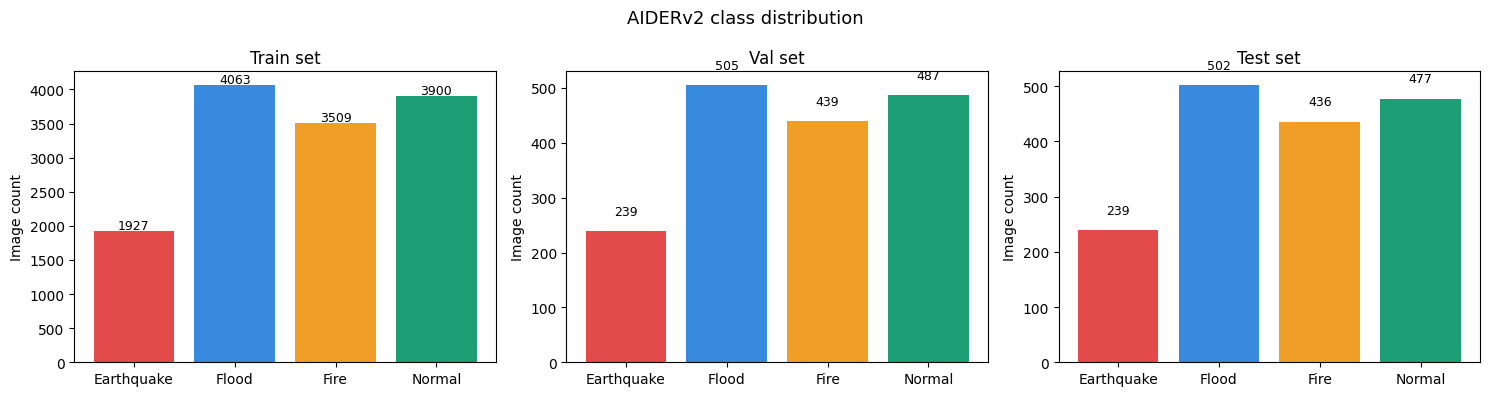

Total training images: 13399


In [ ]:
import os
from collections import Counter
import matplotlib.pyplot as plt

BASE = '/content/AIDER'
splits = ['Train', 'Val', 'Test']
classes = ['Earthquake', 'Flood', 'Fire', 'Normal']

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, split in enumerate(splits):
    counts = []
    for cls in classes:
        path = os.path.join(BASE, split, cls)
        n = len(os.listdir(path)) if os.path.exists(path) else 0
        counts.append(n)

    axes[i].bar(classes, counts, color=['#E24B4A','#378ADD','#EF9F27','#1D9E75'])
    axes[i].set_title(f'{split} set')
    axes[i].set_ylabel('Image count')
    for j, v in enumerate(counts):
        axes[i].text(j, v + 30, str(v), ha='center', fontsize=9)

plt.suptitle('AIDERv2 class distribution', fontsize=13)
plt.tight_layout()
plt.show()

total = sum(len(os.listdir(os.path.join(BASE, 'Train', c))) for c in classes)
print(f"Total training images: {total}")

In [ ]:
import os, glob

BASE = '/content/AIDER'

# Check exact folder names
print("Folders in Train:")
print(os.listdir(f'{BASE}/Train'))

# Check what file extensions exist
all_files = glob.glob(f'{BASE}/Train/*/*')
extensions = set(os.path.splitext(f)[1] for f in all_files[:100])
print("\nFile extensions found:", extensions)

# Show a sample file path
print("\nSample file paths:")
for f in all_files[:3]:
    print(" ", f)

Folders in Train:
['Fire', 'Normal', 'Flood', 'Earthquake']

File extensions found: {'.png'}

Sample file paths:
  /content/AIDER/Train/Fire/image_11402.png
  /content/AIDER/Train/Fire/image_11093.png
  /content/AIDER/Train/Fire/image_12496.png


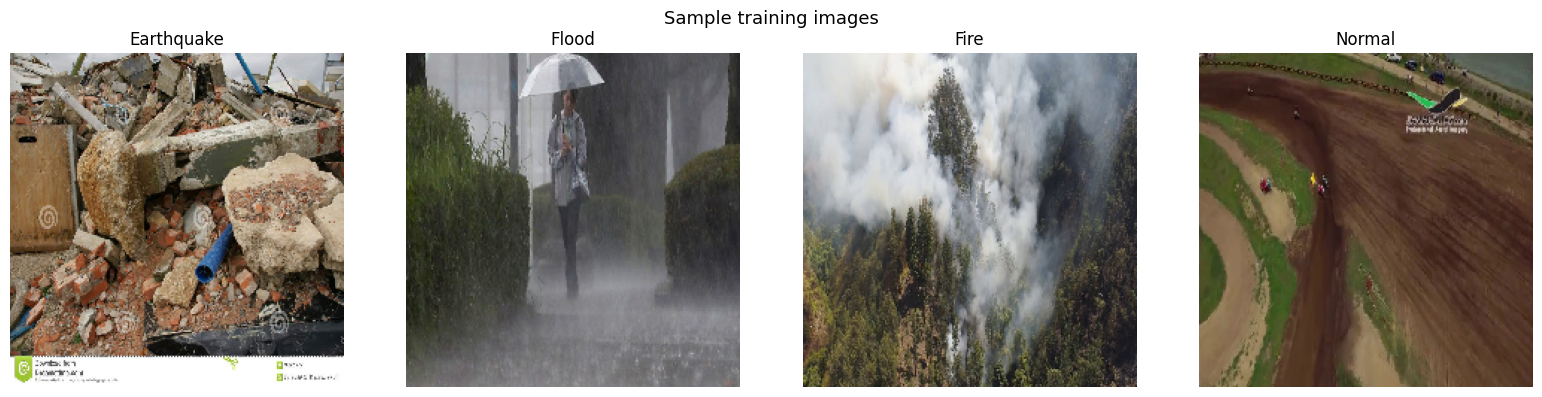

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import glob

classes = ['Earthquake', 'Flood', 'Fire', 'Normal']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, cls in enumerate(classes):
    sample = glob.glob(f'/content/AIDER/Train/{cls}/*.png')[0]
    axes[i].imshow(Image.open(sample))
    axes[i].set_title(cls)
    axes[i].axis('off')

plt.suptitle('Sample training images', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import tensorflow as tf

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
BASE       = '/content/AIDER'

# Training set with augmentation
train_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Train',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=True,
    seed=42
)

# Validation set — no augmentation
val_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Val',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

# Test set — no augmentation
test_ds = tf.keras.utils.image_dataset_from_directory(
    f'{BASE}/Test',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical',
    shuffle=False
)

class_names = train_ds.class_names
print("Classes:", class_names)
print("Train batches:", len(train_ds))
print("Val batches:  ", len(val_ds))
print("Test batches: ", len(test_ds))

# Normalize + prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE

def preprocess(images, labels):
    images = tf.cast(images, tf.float32) / 255.0
    return images, labels

train_ds = train_ds.map(preprocess).prefetch(AUTOTUNE)
val_ds   = val_ds.map(preprocess).prefetch(AUTOTUNE)
test_ds  = test_ds.map(preprocess).prefetch(AUTOTUNE)

print("\nPipeline ready.")

Found 13399 files belonging to 4 classes.
Found 1670 files belonging to 4 classes.
Found 1654 files belonging to 4 classes.
Classes: ['Earthquake', 'Fire', 'Flood', 'Normal']
Train batches: 419
Val batches:   53
Test batches:  52

Pipeline ready.
